# 02. Exploratory Data Analysis (EDA)

## Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks
### Open Project 2026 — Society of Business

---

## Notebook Overview

This notebook profiles demand behavior across both datasets to extract insights that directly inform pricing agent design.

### Analysis Structure
1. Data loading
2. Network-wide utilization overview
3. Hourly demand patterns (intraday cycles)
4. 30-day demand trend
5. Station-level utilization distribution
6. Weekday vs weekend patterns (UrbanEV)
7. Volatility across peak, shoulder, and off-peak periods
8. CBD vs non-CBD station comparison
9. ACN session behavior — weekday vs weekend (fleet vs personal use)

### Key Question
Where, when, and how severely does demand vary — and what does that mean for dynamic pricing?

In [1]:
# ============================================================
# 1. IMPORTS AND DATA LOADING
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:.4f}".format)

# Load processed datasets
urban = pd.read_csv("../data/urban_processed.csv", parse_dates=["datetime"])
acn   = pd.read_csv("../data/acn_processed.csv",   parse_dates=["connectionTime"])

urban["station_id"] = urban["station_id"].astype(str)

print(f"UrbanEV: {urban.shape[0]:,} rows × {urban.shape[1]} columns")
print(f"ACN:     {acn.shape[0]:,} rows × {acn.shape[1]} columns")
print(f"\nUrbanEV date range: {urban['datetime'].min()} → {urban['datetime'].max()}")
print(f"ACN date range:     {acn['connectionTime'].min()} → {acn['connectionTime'].max()}")

UrbanEV: 2,133,833 rows × 19 columns
ACN:     14,848 rows × 20 columns

UrbanEV date range: 2022-06-19 00:05:00 → 2022-07-18 23:55:00
ACN date range:     2018-04-25 11:08:04+00:00 → 2018-12-16 03:01:46+00:00


---
## 1. Network-Wide Utilization Overview

Before plotting trends, we establish the baseline distribution of utilization across the entire UrbanEV network. This tells us whether the system is structurally overloaded, balanced, or underused.

In [2]:
# ============================================================
# 2. NETWORK-WIDE UTILIZATION OVERVIEW
# ============================================================

total_rows   = len(urban)
surge_rows   = (urban["utilization_rate"] >= 0.8).sum()
discount_rows = (urban["utilization_rate"] <= 0.3).sum()
normal_rows  = total_rows - surge_rows - discount_rows

print("=" * 50)
print("  NETWORK UTILIZATION OVERVIEW")
print("=" * 50)
print(f"Total station-time slots:  {total_rows:>12,}")
print(f"Surge zone  (>= 80%):      {surge_rows:>12,}  ({100*surge_rows/total_rows:.1f}%)")
print(f"Normal zone (30–80%):      {normal_rows:>12,}  ({100*normal_rows/total_rows:.1f}%)")
print(f"Discount zone (<= 30%):    {discount_rows:>12,}  ({100*discount_rows/total_rows:.1f}%)")
print(f"\nNetwork avg utilization:   {urban['utilization_rate'].mean():.4f}")
print(f"Network std utilization:   {urban['utilization_rate'].std():.4f}")

  NETWORK UTILIZATION OVERVIEW
Total station-time slots:     2,133,833
Surge zone  (>= 80%):            22,800  (1.1%)
Normal zone (30–80%):           802,022  (37.6%)
Discount zone (<= 30%):       1,309,011  (61.3%)

Network avg utilization:   0.2802
Network std utilization:   0.1761


---
## 2. Hourly Demand Pattern (Intraday Cycle)

Average utilization rate by hour of day across all 247 stations and 30 days. This reveals the intraday demand cycle and directly determines when surge and discount pricing rules activate.

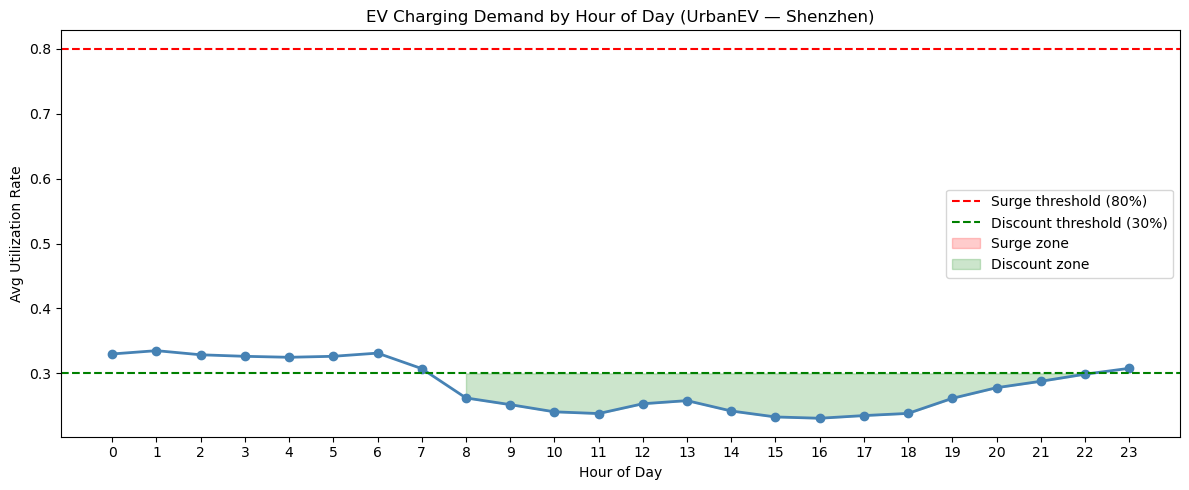

Peak hour:   1:00  (0.3350)
Lowest hour: 16:00  (0.2308)

Insight: Demand peaks at 1am and drops through the afternoon.
Pattern consistent with fleet/residential overnight charging behavior.


In [3]:
# ============================================================
# 3. HOURLY DEMAND PATTERN
# ============================================================

hourly = urban.groupby("hour")["utilization_rate"].mean().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(hourly["hour"], hourly["utilization_rate"],
         marker="o", linewidth=2, color="steelblue")
plt.axhline(0.8, color="red",   linestyle="--", label="Surge threshold (80%)")
plt.axhline(0.3, color="green", linestyle="--", label="Discount threshold (30%)")
plt.fill_between(hourly["hour"], hourly["utilization_rate"], 0.8,
                 where=hourly["utilization_rate"] >= 0.8,
                 alpha=0.2, color="red", label="Surge zone")
plt.fill_between(hourly["hour"], hourly["utilization_rate"], 0.3,
                 where=hourly["utilization_rate"] <= 0.3,
                 alpha=0.2, color="green", label="Discount zone")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Utilization Rate")
plt.title("EV Charging Demand by Hour of Day (UrbanEV — Shenzhen)")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plot1_hourly_demand.png", dpi=150)
plt.show()

peak_hour   = hourly.loc[hourly["utilization_rate"].idxmax(), "hour"]
lowest_hour = hourly.loc[hourly["utilization_rate"].idxmin(), "hour"]
print(f"Peak hour:   {peak_hour}:00  ({hourly['utilization_rate'].max():.4f})")
print(f"Lowest hour: {lowest_hour}:00  ({hourly['utilization_rate'].min():.4f})")
print("\nInsight: Demand peaks at 1am and drops through the afternoon.")
print("Pattern consistent with fleet/residential overnight charging behavior.")

---
## 3. 30-Day Demand Trend

Daily average utilization across the full 30-day UrbanEV period. This checks for growth trends, weekly cycles, or anomalies in the data.

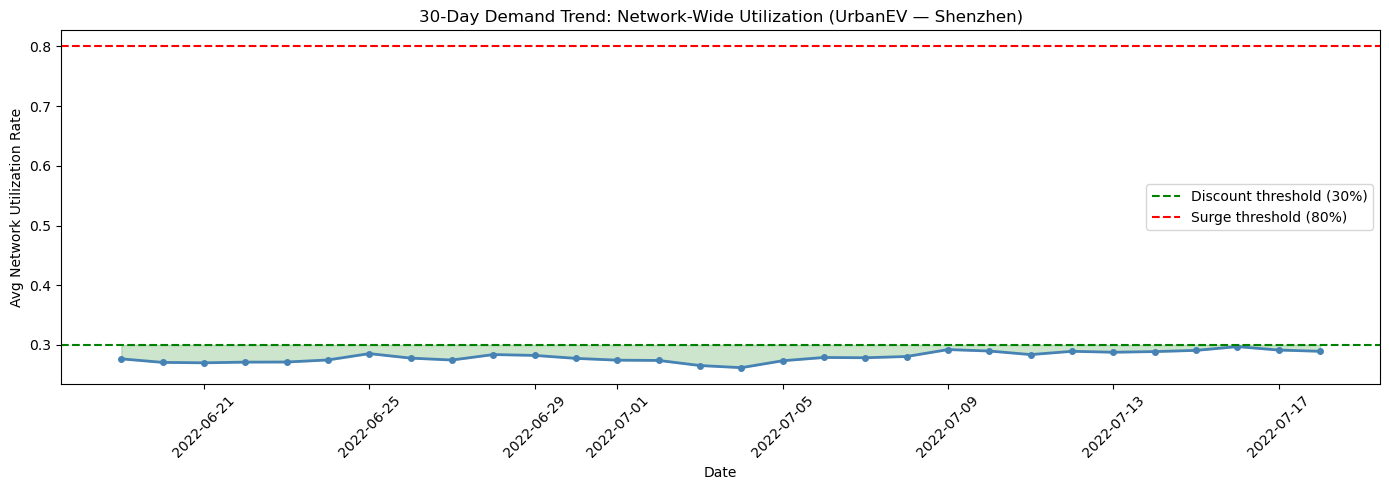

Daily utilization stats:
count   30.0000
mean     0.2802
std      0.0088
min      0.2620
25%      0.2742
50%      0.2788
75%      0.2887
max      0.2973
Name: avg_utilization, dtype: float64

Insight: Network utilization is remarkably stable across 30 days.
No growth trend or weekly seasonality visible at network level.
Station-level variation is where the signal lies.


In [4]:
# ============================================================
# 4. 30-DAY DEMAND TREND
# ============================================================

daily = urban.groupby(urban["datetime"].dt.date)["utilization_rate"].mean().reset_index()
daily.columns = ["date", "avg_utilization"]

plt.figure(figsize=(14, 5))
plt.plot(daily["date"], daily["avg_utilization"],
         color="steelblue", linewidth=2, marker="o", markersize=4)
plt.axhline(0.3, color="green", linestyle="--", label="Discount threshold (30%)")
plt.axhline(0.8, color="red",   linestyle="--", label="Surge threshold (80%)")
plt.fill_between(daily["date"], daily["avg_utilization"], 0.3,
                 where=daily["avg_utilization"] <= 0.3,
                 alpha=0.2, color="green")
plt.xlabel("Date")
plt.ylabel("Avg Network Utilization Rate")
plt.title("30-Day Demand Trend: Network-Wide Utilization (UrbanEV — Shenzhen)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plot2_30day_trend.png", dpi=150)
plt.show()

print("Daily utilization stats:")
print(daily["avg_utilization"].describe().round(4))
print("\nInsight: Network utilization is remarkably stable across 30 days.")
print("No growth trend or weekly seasonality visible at network level.")
print("Station-level variation is where the signal lies.")

---
## 4. Station-Level Utilization Distribution

Network averages mask significant station-level variation. This section identifies which stations are chronically overloaded vs chronically underused — the key input for spatial pricing strategy.

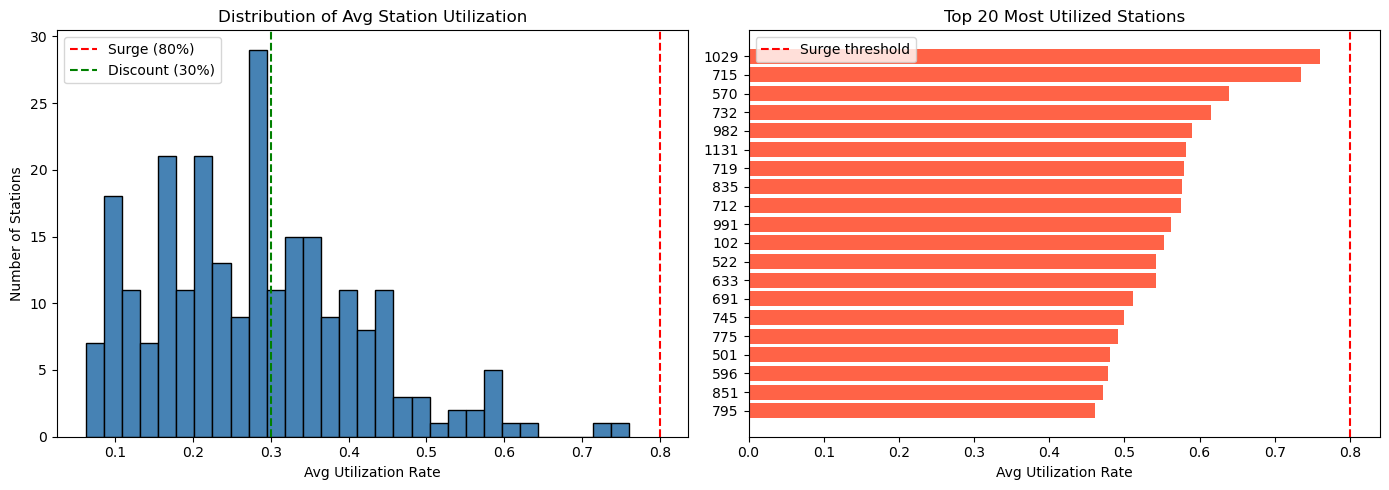

Station utilization summary:
count   247.0000
mean      0.2802
std       0.1333
min       0.0617
25%       0.1749
50%       0.2742
75%       0.3612
max       0.7603
Name: utilization_rate, dtype: float64

Stations chronically in surge    (avg >= 80%): 0
Stations chronically in discount (avg <= 30%): 153 / 247

Insight: No station averages above 80%. Surge events are short spikes,
not structural overload. 62% of stations are chronically underused.


In [5]:
# ============================================================
# 5. STATION-LEVEL UTILIZATION DISTRIBUTION
# ============================================================

station_util = urban.groupby("station_id")["utilization_rate"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution across stations
axes[0].hist(station_util.values, bins=30, color="steelblue", edgecolor="black")
axes[0].axvline(0.8, color="red",   linestyle="--", label="Surge (80%)")
axes[0].axvline(0.3, color="green", linestyle="--", label="Discount (30%)")
axes[0].set_xlabel("Avg Utilization Rate")
axes[0].set_ylabel("Number of Stations")
axes[0].set_title("Distribution of Avg Station Utilization")
axes[0].legend()

# Right: top 20 most utilized stations
top20 = station_util.head(20)
axes[1].barh(top20.index[::-1], top20.values[::-1], color="tomato")
axes[1].axvline(0.8, color="red", linestyle="--", label="Surge threshold")
axes[1].set_xlabel("Avg Utilization Rate")
axes[1].set_title("Top 20 Most Utilized Stations")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/plot3_station_utilization.png", dpi=150)
plt.show()

chronic_surge    = (station_util >= 0.8).sum()
chronic_discount = (station_util <= 0.3).sum()

print("Station utilization summary:")
print(station_util.describe().round(4))
print(f"\nStations chronically in surge    (avg >= 80%): {chronic_surge}")
print(f"Stations chronically in discount (avg <= 30%): {chronic_discount} / {len(station_util)}")
print("\nInsight: No station averages above 80%. Surge events are short spikes,")
print("not structural overload. 62% of stations are chronically underused.")

---
## 5. Weekday vs Weekend Demand Pattern

Hourly utilization split by weekday and weekend reveals whether day type drives meaningful demand differences — relevant for time-of-use pricing design.

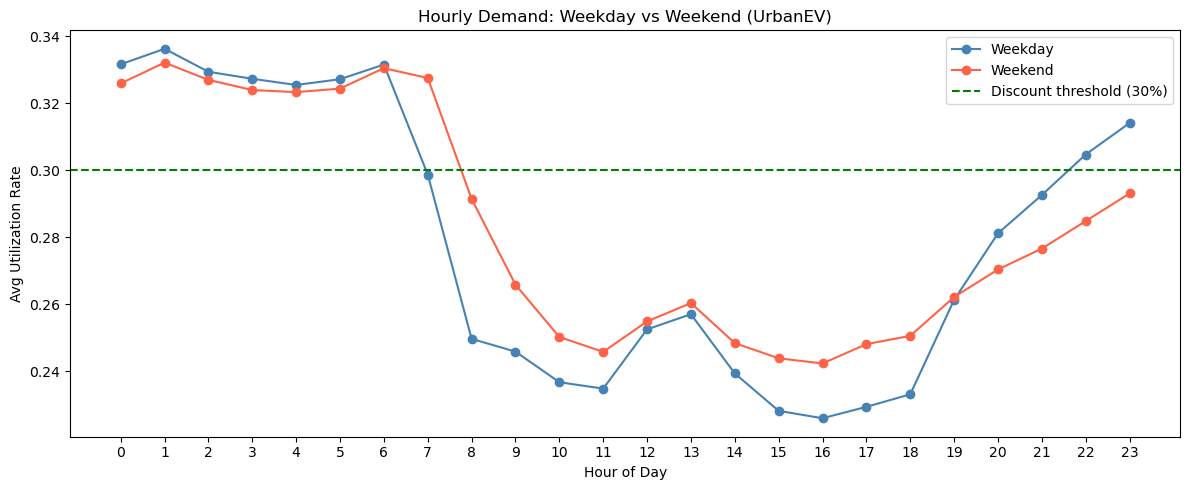

Weekday vs Weekend avg utilization:
is_weekend
0   0.2789
1   0.2834
Name: utilization_rate, dtype: float64

Insight: Weekday vs weekend difference is negligible (0.279 vs 0.283).
Day type is not a strong pricing signal for this network.


In [6]:
# ============================================================
# 6. WEEKDAY VS WEEKEND PATTERN (UrbanEV)
# ============================================================

hourly_wk = urban.groupby(["hour","is_weekend"])["utilization_rate"].mean().reset_index()

plt.figure(figsize=(12, 5))
for weekend, label, color in [(0,"Weekday","steelblue"),(1,"Weekend","tomato")]:
    subset = hourly_wk[hourly_wk["is_weekend"]==weekend]
    plt.plot(subset["hour"], subset["utilization_rate"],
             marker="o", label=label, color=color)

plt.axhline(0.3, color="green", linestyle="--", label="Discount threshold (30%)")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Utilization Rate")
plt.title("Hourly Demand: Weekday vs Weekend (UrbanEV)")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plot4_weekday_weekend.png", dpi=150)
plt.show()

print("Weekday vs Weekend avg utilization:")
print(urban.groupby("is_weekend")["utilization_rate"].mean().round(4))
print("\nInsight: Weekday vs weekend difference is negligible (0.279 vs 0.283).")
print("Day type is not a strong pricing signal for this network.")

---
## 6. Demand Volatility: Peak vs Shoulder vs Off-Peak

Volatility — measured as standard deviation and coefficient of variation — determines how unpredictable demand is within each period. High volatility justifies dynamic pricing even when average utilization is similar across periods.

**Period definitions based on intraday analysis:**
- **Peak:** 10pm–6am (highest avg utilization)
- **Shoulder:** 7–10am and 7–9pm (transitional periods)
- **Off-Peak:** 11am–6pm (lowest avg utilization)

Volatility across demand periods:
                      mean    std    min    max     cv
period                                                
Off-Peak (11am–6pm) 0.2410 0.1519 0.0000 1.0000 0.6301
Peak (10pm–6am)     0.3232 0.1941 0.0000 1.0769 0.6007
Shoulder            0.2699 0.1650 0.0000 1.0769 0.6114


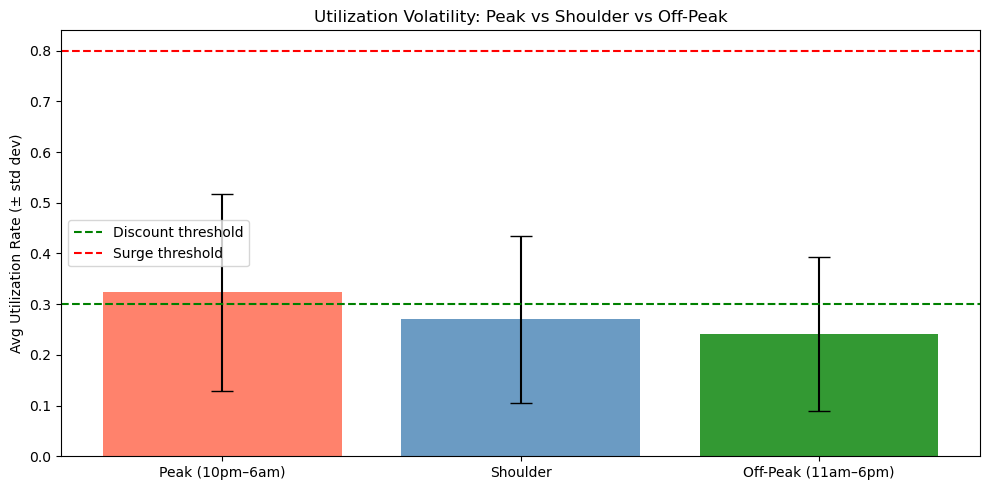


Insight: Coefficient of variation ~0.60 across all periods.
High relative volatility at station level justifies dynamic pricing
even when network averages appear similar across periods.


In [7]:
# ============================================================
# 7. VOLATILITY ACROSS DEMAND PERIODS
# ============================================================

def period_label(hour):
    if 22 <= hour or hour <= 6:
        return "Peak (10pm–6am)"
    elif 7 <= hour <= 10 or 19 <= hour <= 21:
        return "Shoulder"
    else:
        return "Off-Peak (11am–6pm)"

urban["period"] = urban["hour"].apply(period_label)

volatility = urban.groupby("period")["utilization_rate"].agg(
    mean="mean",
    std="std",
    min="min",
    max="max",
    cv=lambda x: x.std() / x.mean()
).round(4)

print("Volatility across demand periods:")
print(volatility)

# Plot
period_order = ["Peak (10pm–6am)", "Shoulder", "Off-Peak (11am–6pm)"]
means = [volatility.loc[p, "mean"] for p in period_order]
stds  = [volatility.loc[p, "std"]  for p in period_order]

plt.figure(figsize=(10, 5))
plt.bar(period_order, means, yerr=stds, capsize=8,
        color=["tomato", "steelblue", "green"], alpha=0.8)
plt.axhline(0.3, color="green", linestyle="--", label="Discount threshold")
plt.axhline(0.8, color="red",   linestyle="--", label="Surge threshold")
plt.ylabel("Avg Utilization Rate (± std dev)")
plt.title("Utilization Volatility: Peak vs Shoulder vs Off-Peak")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/plot5_volatility.png", dpi=150)
plt.show()

print("\nInsight: Coefficient of variation ~0.60 across all periods.")
print("High relative volatility at station level justifies dynamic pricing")
print("even when network averages appear similar across periods.")

---
## 7. CBD vs Non-CBD Station Analysis

The `information.csv` file flags whether each station is in a Central Business District. This tests whether location type predicts congestion — relevant for spatial pricing policy.

In [8]:
# ============================================================
# 8. CBD VS NON-CBD COMPARISON
# ============================================================

info = pd.read_csv("../data/information.csv")
info["station_id"] = info["grid"].astype(str)

urban_info = urban.drop(columns=["CBD"], errors="ignore").merge(
    info[["station_id", "CBD"]], on="station_id", how="left"
)

print("Surge rate and avg utilization by CBD status:")
cbd_stats = urban_info.groupby("CBD")["utilization_rate"].agg(
    mean="mean",
    surge_pct=lambda x: (x >= 0.8).mean() * 100
).round(3)
print(cbd_stats)

print("\nInsight: CBD stations are LESS utilized than non-CBD stations.")
print("Surge events are concentrated in residential/transit areas, not commercial zones.")
print("Location-based pricing should target non-CBD high-demand clusters.")

Surge rate and avg utilization by CBD status:
      mean  surge_pct
CBD                  
0   0.2930     1.3720
1   0.2430     0.1640

Insight: CBD stations are LESS utilized than non-CBD stations.
Surge events are concentrated in residential/transit areas, not commercial zones.
Location-based pricing should target non-CBD high-demand clusters.


---
## 8. ACN Session Behavior — Weekday vs Weekend

ACN data covers only JPL workplace charging. Weekday sessions represent structured fleet/commuter behavior; weekend sessions reflect personal use. Comparing the two reveals pricing implications for idle time and session efficiency.

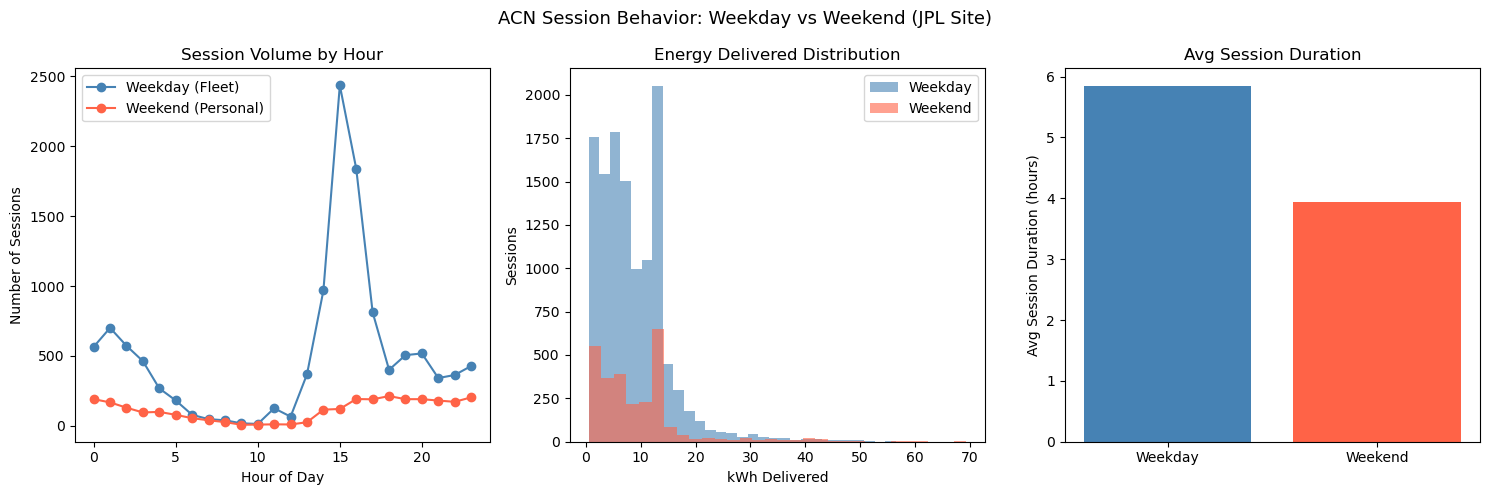

Weekday vs Weekend session summary:
            session_hours  kWhDelivered  idle_hours  revenue_per_session
is_weekend                                                              
0                  5.8400        8.7800      2.5400             131.6600
1                  3.9400        9.6800      1.4900             145.2000

Insight: Weekday sessions are longer (5.84 hrs) but deliver less energy (8.78 kWh).
Cars sit idle after charging. Weekend sessions are shorter but more energy-efficient.
Supports idle time penalty pricing as a policy recommendation.


In [9]:
# ============================================================
# 9. ACN SESSION BEHAVIOR — WEEKDAY VS WEEKEND
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Session volume by hour
for weekend, label, color in [(0,"Weekday (Fleet)","steelblue"),(1,"Weekend (Personal)","tomato")]:
    subset = acn[acn["is_weekend"]==weekend]
    hourly_acn = subset.groupby("hour").size()
    axes[0].plot(hourly_acn.index, hourly_acn.values,
                 label=label, color=color, marker="o")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Sessions")
axes[0].set_title("Session Volume by Hour")
axes[0].legend()

# Plot 2: kWh delivered distribution
for weekend, label, color in [(0,"Weekday","steelblue"),(1,"Weekend","tomato")]:
    subset = acn[acn["is_weekend"]==weekend]["kWhDelivered"]
    axes[1].hist(subset, bins=30, alpha=0.6, label=label, color=color)
axes[1].set_xlabel("kWh Delivered")
axes[1].set_ylabel("Sessions")
axes[1].set_title("Energy Delivered Distribution")
axes[1].legend()

# Plot 3: Avg session duration
dur_stats = acn.groupby("is_weekend")["session_hours"].mean()
axes[2].bar(["Weekday", "Weekend"], dur_stats.values,
            color=["steelblue", "tomato"])
axes[2].set_ylabel("Avg Session Duration (hours)")
axes[2].set_title("Avg Session Duration")

plt.suptitle("ACN Session Behavior: Weekday vs Weekend (JPL Site)", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/plot6_weekday_weekend_acn.png", dpi=150)
plt.show()

print("Weekday vs Weekend session summary:")
print(acn.groupby("is_weekend")[[
    "session_hours", "kWhDelivered", "idle_hours", "revenue_per_session"
]].mean().round(2))

print("\nInsight: Weekday sessions are longer (5.84 hrs) but deliver less energy (8.78 kWh).")
print("Cars sit idle after charging. Weekend sessions are shorter but more energy-efficient.")
print("Supports idle time penalty pricing as a policy recommendation.")

---
## EDA Summary — Key Findings

| # | Finding | Pricing Implication |
|---|---|---|
| 1 | 62% of station-hours below 30% utilization | Discount activation is the primary lever, not surge control |
| 2 | Demand peaks at 1am, lowest at 4pm | Fleet/residential overnight pattern — night tariffs matter most |
| 3 | 30-day trend is flat (std=0.009) | No growth signal; pricing must work within existing demand |
| 4 | Surge concentrated in 10 stations | Spatial redistribution more effective than blanket surge pricing |
| 5 | CBD stations less utilized than non-CBD | Location alone does not predict congestion |
| 6 | Weekday idle time averages 2.69 hrs | Idle time penalty pricing can improve charger turnover |
| 7 | Station-level CV ~0.60 across all periods | High volatility justifies real-time dynamic pricing |

These findings directly shape the thresholds, rules, and agent architecture in notebooks 03 and 04.